In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

# Load datasets specifying the semicolon separator
control_df = pd.read_csv(r'C:\Users\yashf\Desktop\Aireen Fatma\Growfinix_tasks\Task - 2\control_group.csv', sep=';')
test_df = pd.read_csv(r'C:\Users\yashf\Desktop\Aireen Fatma\Growfinix_tasks\Task - 2\test_group.csv', sep=';')

# Clean column names
control_df.columns = control_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

# Replace '#' with 'Number' in all column names
control_df.columns = control_df.columns.str.replace('#', 'Number')
test_df.columns = test_df.columns.str.replace('#', 'Number')

print("Control shape:", control_df.shape)
print("Test shape:", test_df.shape)

Control shape: (30, 10)
Test shape: (30, 10)


In [22]:
# Fill missing values with column mean
control_df = control_df.fillna(control_df.mean(numeric_only=True))
test_df = test_df.fillna(test_df.mean(numeric_only=True))

control_df['Group'] = 'Control (Variant A)'
test_df['Group'] = 'Test (Variant B)'

combined_df = pd.concat([control_df, test_df], ignore_index=True)

# Calculate Key Business Metrics
combined_df['CTR (%)'] = (combined_df['Number of Website Clicks'] / combined_df['Number of Impressions']) * 100
combined_df['Conversion Rate (%)'] = (combined_df['Number of Purchase'] / combined_df['Number of Website Clicks']) * 100

combined_df[['Group', 'Number of Impressions', 'Number of Website Clicks', 'Number of Purchase', 'CTR (%)', 'Conversion Rate (%)']].head()

,Group,Number of Impressions,Number of Website Clicks,Number of Purchase,CTR (%),Conversion Rate (%)
0,Control (Variant A),82702.000000,7016.000000,618.000000,8.483471,8.808438
1,Control (Variant A),121040.000000,8110.000000,511.000000,6.700264,6.300863
2,Control (Variant A),131711.000000,6508.000000,372.000000,4.941121,5.716042
3,Control (Variant A),72878.000000,3065.000000,340.000000,4.205659,11.092985
4,Control (Variant A),109559.758621,5320.793103,522.793103,4.856521,9.825473


In [23]:
metrics = ['Number of Impressions', 'Number of Website Clicks', 'Number of Purchase', 'CTR (%)', 'Conversion Rate (%)']

print("--- A/B TESTING STATISTICAL RESULTS (Two-Sample t-Test) ---\n")

for metric in metrics:
    control_vals = combined_df[combined_df['Group'] == 'Control (Variant A)'][metric]
    test_vals = combined_df[combined_df['Group'] == 'Test (Variant B)'][metric]
    
    t_stat, p_val = stats.ttest_ind(control_vals, test_vals)
    significance = "Statistically Significant! 🎉" if p_val < 0.05 else "Not Statistically Significant ❌"
    
    print(f"Metric: {metric}")
    print(f"  • Control Mean: {control_vals.mean():.2f}")
    print(f"  • Test Mean:    {test_vals.mean():.2f}")
    print(f"  • p-value:      {p_val:.4f}")
    print(f"  • Result:       {significance}\n")

--- A/B TESTING STATISTICAL RESULTS (Two-Sample t-Test) ---

Metric: Number of Impressions
  • Control Mean: 109559.76
  • Test Mean:    74584.80
  • p-value:      0.0000
  • Result:       Statistically Significant! 🎉

Metric: Number of Website Clicks
  • Control Mean: 5320.79
  • Test Mean:    6032.33
  • p-value:      0.1141
  • Result:       Not Statistically Significant ❌

Metric: Number of Purchase
  • Control Mean: 522.79
  • Test Mean:    521.23
  • p-value:      0.9756
  • Result:       Not Statistically Significant ❌

Metric: CTR (%)
  • Control Mean: 5.09
  • Test Mean:    10.24
  • p-value:      0.0002
  • Result:       Statistically Significant! 🎉

Metric: Conversion Rate (%)
  • Control Mean: 11.42
  • Test Mean:    9.23
  • p-value:      0.1421
  • Result:       Not Statistically Significant ❌



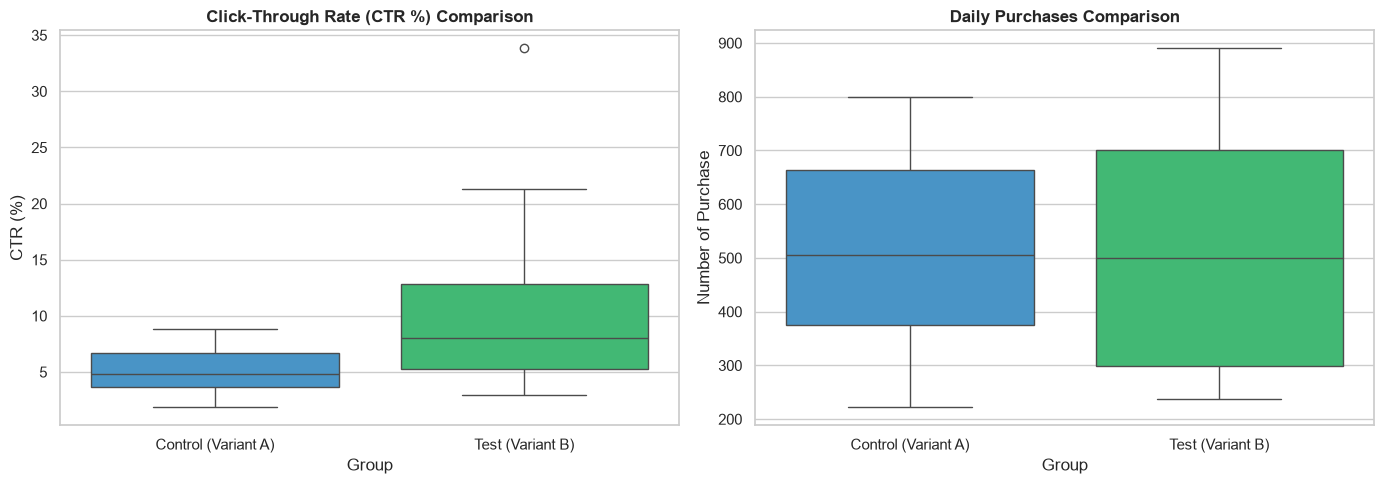

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Click-Through Rate
sns.boxplot(
    ax=axes[0], 
    x='Group', 
    y='CTR (%)', 
    hue='Group', 
    data=combined_df, 
    palette=['#3498db', '#2ecc71'], 
    legend=False
)
axes[0].set_title('Click-Through Rate (CTR %) Comparison', fontsize=12, fontweight='bold')

# Plot 2: Daily Purchases
sns.boxplot(
    ax=axes[1], 
    x='Group', 
    y='Number of Purchase', 
    hue='Group', 
    data=combined_df, 
    palette=['#3498db', '#2ecc71'], 
    legend=False
)
axes[1].set_title('Daily Purchases Comparison', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('ab_test_results.png', dpi=300)
plt.show()